In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:

import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import time
import pickle

from concurrent.futures import ProcessPoolExecutor, as_completed

import discretize
# from simpeg import dask
from simpeg import (
    maps,
    Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)
from simpeg.electromagnetics import time_domain as tdem
from simpeg.utils.solver_utils import get_default_solver

from simpeg.meta import MultiprocessingMetaSimulation, MetaSimulation

from parametric_ellipsoid import ParametricEllipsoid

Solver = get_default_solver()



In [ ]:
rho_back = 1000
sigma_back = 1./rho_back

rho_target = 0.1
sigma_target = 1./rho_target

rho_overburden = 1000
sigma_overburden = 1./rho_overburden

sigma_air = 1e-8

target_dips = np.r_[115] #, 45]
target_z = np.r_[-300, -120]

In [ ]:
# rx_locs = np.loadtxt(f"{directory}/rx_locs.txt")
# rx_locs[:, 1] =
tx_height = 30

rx_x = (np.linspace(-500, 500, 26))[3:-3][::2]
rx_y = (np.linspace(-400, 400, 5))[1:-1]
# rx_y = np.r_[-80, -40, 0, 40, 80]

rx_z = tx_height

rx_locs = discretize.utils.ndgrid([rx_x, rx_y, rx_z])
rx_x

# rx_times = np.loadtxt(f"{directory}/rx_times.txt")
rx_times = np.logspace(np.log10(2e-5), np.log10(2e-3), 20)

In [7]:
rx_x

array([-380., -340., -300., -260., -220., -180., -140., -100.,  -60.,
        -20.,   20.,   60.,  100.,  140.,  180.,  220.,  260.,  300.,
        340.,  380.])

In [8]:
rx_y

array([-200.,    0.,  200.])

In [9]:
def diffusion_distance(sigma, t):
    return 1260*np.sqrt(t/sigma)

In [10]:
diffusion_distance(sigma_target, 8e-3)

np.float64(35.638181771801996)

In [11]:
diffusion_distance(sigma_back, 8e-3)

np.float64(3563.8181771801997)

In [12]:
base_cell_width = 20
domain_extent = 8000

n_base_cells = 2 ** int(
    np.ceil(np.log(domain_extent / base_cell_width) / np.log(2.0))
)  # needs to be powers of 2 for the tree mesh

h = [(base_cell_width, n_base_cells)]
mesh = discretize.TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# refine near transmitters and receivers
mesh.refine_points(
    rx_locs, level=-1, padding_cells_by_level=[2, 2, 2],
    finalize=False, diagonal_balance=True
)

# Refine core region of the mesh

bounding_points = np.array([
    [-500, rx_y.min(), target_z.min() - base_cell_width * 4],
    [500, rx_y.max(), 0],
])
mesh.refine_bounding_box(
    bounding_points, level=-1,
    diagonal_balance=True, finalize=False, padding_cells_by_level=[2, 2, 2]
)

mesh.finalize()

In [13]:
mesh

OcTreeMesh: 0.04% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  3   :       448            ---------------------------   --------------------
  4   :       448         x:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  5   :       332         y:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  6   :       880         z:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  7   :      3040      
  8   :      6424      
  9   :      40768     
-----------------------
Total :      52340

In [14]:
def dipping_target_indices(
    mesh, target_x_center, target_z_center, dip, target_thickness, target_xlim=None, target_ylim=None, target_zlim=None
):
    """
    add a dipping target to the model. For now assumes the target dips in the x-direction
    """
    slope = np.tan(-dip*np.pi/180)
    target_z = target_z_center + target_thickness / 2 * np.r_[-1, 1]

    z_bottom = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.min()
    z_top = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.max()

    indices = (
        (mesh.cell_centers[:, 2] >= z_bottom) &
        (mesh.cell_centers[:, 2] <= z_top)
    )

    if target_xlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 0] >= target_xlim.min()) &
            (mesh.cell_centers[:, 0] <= target_xlim.max())
        )
    if target_ylim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 1] >= target_ylim.min()) &
            (mesh.cell_centers[:, 1] <= target_ylim.max())
        )
    if target_zlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 2] >= target_zlim.min()) &
            (mesh.cell_centers[:, 2] <= target_zlim.max())
        )
    return indices

In [15]:
models = {}

target_x = np.r_[-300, 300]
target_y = np.r_[-100, 100]
target_thickness = 200

overburden_x = np.r_[-640, 640]
overburden_y = np.r_[-640, 640]
overburden_thickness = 40

# background model
background = np.ones(mesh.n_cells) * sigma_air
background[mesh.cell_centers[:, 2] < 0] = sigma_back
models["background"] = background

for dip in target_dips:
    conductivity_model = background.copy()
    indices = dipping_target_indices(
        mesh, target_x_center=0, target_z_center=np.mean(target_z),
        target_thickness=target_thickness, dip=dip,
        target_xlim=target_x,
        target_ylim=target_y,
        target_zlim=target_z
    )
    conductivity_model[indices] = sigma_target

    # add overburden
    overburden_indices = (
        (mesh.cell_centers[:, 0] >= overburden_x[0]) &
        (mesh.cell_centers[:, 0] < overburden_x[1]) &
        (mesh.cell_centers[:, 1] >= overburden_y[0]) &
        (mesh.cell_centers[:, 1] < overburden_y[1]) &
        (mesh.cell_centers[:, 2] >= -overburden_thickness) &
        (mesh.cell_centers[:, 2] < 0)
    )
    conductivity_model[overburden_indices] = sigma_overburden
    models[f"target_{dip}"] = conductivity_model



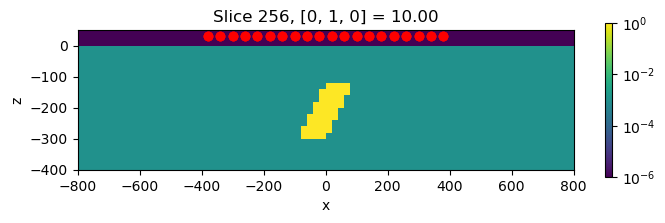

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2))

plt.colorbar(
    mesh.plot_slice(
        conductivity_model,
        # grid=True,
        normal="y",
        pcolor_opts={"norm":LogNorm(1e-6, 1e0)},
        ax=ax)[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])

ax.plot(rx_locs[:, 0], rx_locs[:, 2], "ro")
ax.set_aspect(1)

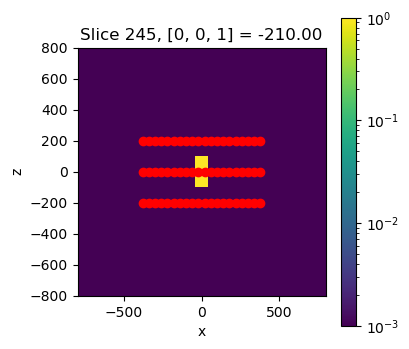

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# mesh_local = mesh_list[-1]

plt.colorbar(
    mesh.plot_slice(
        conductivity_model,
        # grid=True,
        normal="z",
        pcolor_opts={"norm":LogNorm(1e-3, 1e0)},
        ax=ax,
        ind=245
    )[0],
    ax=ax
)

xlim = 800*np.r_[-1, 1]
ax.set_xlim(xlim)
ax.set_ylim(xlim)

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "ro")
ax.set_aspect(1)


In [18]:
source_list = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times, orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list.append(src)

survey = tdem.Survey(source_list)

In [19]:
# set up local meshes
global_mesh = mesh
active_cells_map = maps.InjectActiveCells(global_mesh, global_mesh.cell_centers[:, 2]<0, value_inactive=np.log(1e-8))

refine_depth = 300
# def get_local_mesh(src):
mesh_list = []
x1 = np.mean(rx_locs[:, 0]) - (np.sum(global_mesh.h[0]) / 2)
x2 = np.mean(rx_locs[:, 1]) - (np.sum(global_mesh.h[1]) / 2)
x3 = np.mean(rx_locs[:, 2]) - (np.sum(global_mesh.h[2]) / 2)

for src in survey.source_list:
# src = survey.source_list[0]
    mesh_local = discretize.TreeMesh(global_mesh.h, origin=global_mesh.origin, diagonal_balance=True)
    refine_points = discretize.utils.ndgrid(
        np.r_[src.location[0]],
        np.r_[src.location[1]],
        np.linspace(-refine_depth, src.location[2], 40)
    )
    mesh_local.refine_points(
        refine_points,
        level=-1,
        padding_cells_by_level=[2, 2, 2],
        finalize=True,
        diagonal_balance=True
    )
    mesh_list.append(mesh_local)

    mesh_local.x0

In [20]:
mesh_local

OcTreeMesh,0.00% filled
Level,Number of cells
2,28
3,252
4,252
5,231
6,363
7,653
8,662
9,528
Total,2969


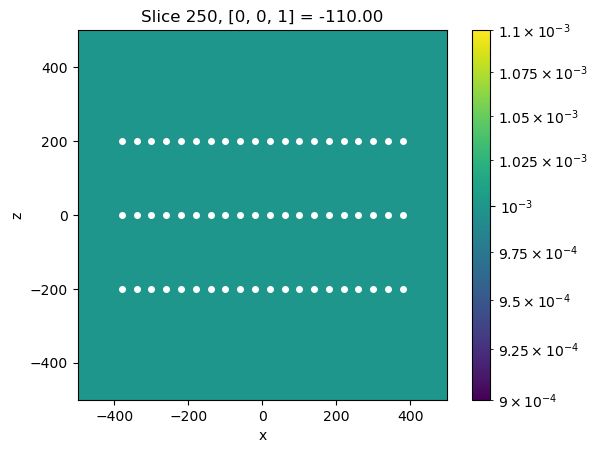

In [21]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        models["target_115"], ax=ax, pcolor_opts={"norm":LogNorm()},
        normal="Z", ind=250
    )[0],
    ax=ax
)

ax.set_xlim(500*np.r_[-1, 1])
ax.set_ylim(500*np.r_[-1, 1])

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "wo", ms=4)
ax.set_aspect(1)

In [22]:
nsteps = 20
time_steps = [
    # (1e-6, nsteps),
    # (3e-6, nsteps),
    (1e-5, nsteps),
    (3e-5, nsteps),
    (1e-4, 20),
]


mappings = []
sims = []

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)
    mappings.append(tile_map)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )

    local_survey = tdem.Survey([survey.source_list[ii]])
    sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap() * local_actmap
        )
    )


sim = MultiprocessingMetaSimulation(sims, mappings)

/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:229: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  super().__init__(simulations, mappings)
/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:248: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  sim_chunk = MetaSimulation(


/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened 

In [23]:
model = np.log(conductivity_model[active_cells_map.active_cells])


In [24]:
%%time
sims[0].dpred(mappings[0] * model)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)


CPU times: user 1.1 s, sys: 37.5 ms, total: 1.14 s
Wall time: 1.14 s


array([-9.97166480e-07, -5.20386921e-07, -1.05744100e-07, -3.51496822e-08,
       -1.47478704e-08, -6.66427571e-09, -3.23474415e-09, -1.66009341e-09,
       -8.95806996e-10, -4.90157928e-10, -2.76729714e-10, -1.54008108e-10,
       -8.31312946e-11, -4.33636279e-11, -2.25812354e-11, -1.18072227e-11,
       -6.57722344e-12, -3.58237840e-12, -1.92523430e-12, -1.03136621e-12])

In [25]:

dobs = sim.dpred(model)
# np.save("dobs-caber.npy", dobs)
# dobs = np.load("dobs-caber.npy")

In [26]:
dobs_obj = Data(survey=survey, dobs=dobs)

In [27]:
n_times_invert = len(rx_times)
dobs_reshaped = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)

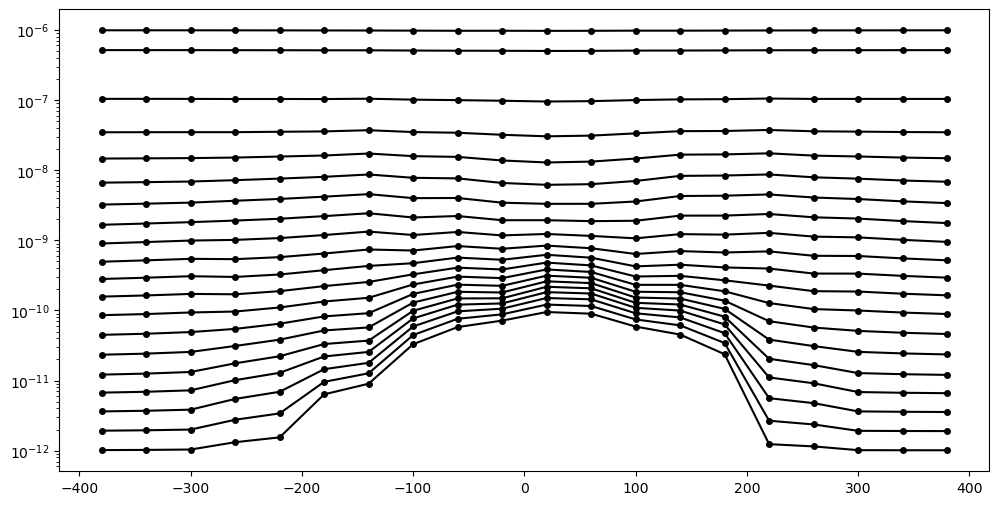

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.semilogy(rx_x, -dobs_reshaped[1, :, :], "-ok", ms=4);

In [29]:
relative_error = 0.05
noise_floor = 1e-12

In [30]:
len(rx_times)

20

In [31]:
times_invert = slice(15, None)
rx_times[times_invert]

array([0.00075854, 0.00096659, 0.0012317 , 0.00156952, 0.002     ])

In [32]:
source_list_invert = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times[times_invert], orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list_invert.append(src)

survey_invert = tdem.Survey(source_list_invert)

In [33]:
dobs_invert = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)[:, :, times_invert].flatten()
data_invert = Data(
    survey_invert, dobs=dobs_invert,
    standard_deviation=np.abs(dobs_invert)*relative_error + noise_floor
)

In [34]:
param_mappings = []
param_sims = []

global_ellipsoid = ParametricEllipsoid(
    global_mesh,
    active_cells=active_cells_map.active_cells,
    # slopeFact=10,
)

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )
    param_mappings.append(tile_map * global_ellipsoid)

    local_survey = tdem.Survey([survey_invert.source_list[ii]])
    param_sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap(local_mesh) * local_actmap
        )
    )

sim_parametric = MultiprocessingMetaSimulation(param_sims, param_mappings)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened 

In [35]:
# p_0, rx, ry, rz, phix, phiy, phiz, x_0, y_0, z_0, p_1, a
parametric_model = np.r_[
    np.log(sigma_back), 100, 100, 300, 0, 0, 0, 0, 0, -150, np.log(sigma_target), 1
]

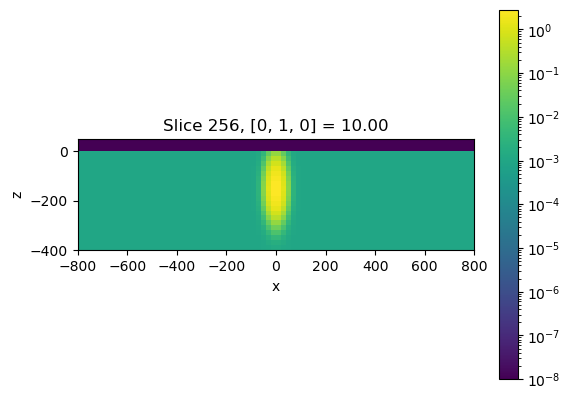

In [36]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * parametric_model, normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

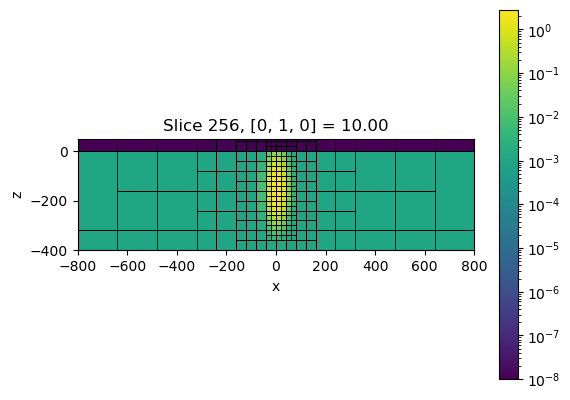

In [37]:
ind = 30
local_mesh = mesh_list[ind]
local_sim = param_sims[ind]
local_mapping = param_mappings[ind]

fig, ax = plt.subplots(1, 1)
plt.colorbar(local_mesh.plot_slice(
    local_sim.sigmaMap * local_mapping * parametric_model, normal="y", pcolor_opts={"norm":LogNorm()},
    ax=ax,
    # grid=True,
    grid_opts={"color":"k", "lw":0.5},
)[0], ax=ax)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [38]:
dpred_parametric = sim_parametric.dpred(parametric_model)

In [39]:
n_times_invert = len(rx_times[times_invert])
dpred_parametric_reshaped = dpred_parametric.reshape(len(rx_y), len(rx_x), n_times_invert)

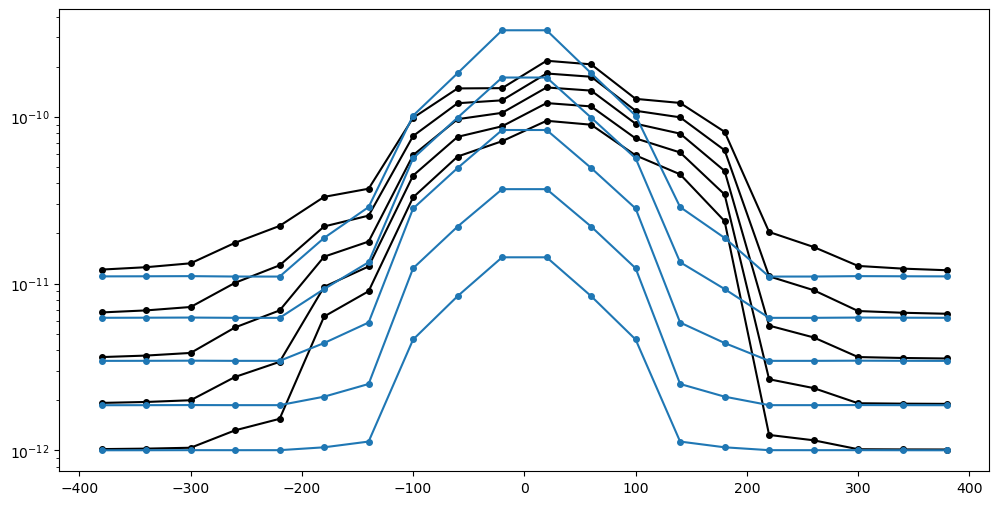

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, times_invert], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_parametric_reshaped[ind, :, :], "-oC0", ms=4);

In [41]:
rel_err_parametric = 0.2
data_invert.standard_deviation = np.abs(dobs_invert)*rel_err_parametric + noise_floor
dmis = data_misfit.L2DataMisfit(simulation=sim_parametric, data=data_invert)
regmesh = discretize.TensorMesh([len(parametric_model)])
reg = regularization.Smallness(
    regmesh
)

In [42]:
# opt = optimization.InexactGaussNewton(maxIter=5, cg_maxiter=30)
# p_0, rx, ry, rz, phix, phiy, phiz, x_0, y_0, z_0, p_1, a

opt = optimization.ProjectedGNCG(
    maxIter=5,
    upper=np.hstack([11*[np.inf], [4]]),
    # cg_maxiter=30,
)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt, beta=0)


/tmp/ipykernel_3691168/1814593388.py:4: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  opt = optimization.ProjectedGNCG(


In [43]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
save_iteration = directives.SaveOutputDictEveryIteration(
    # saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

In [44]:
# The directives are defined as a list.
directives_list = [
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [45]:
m0 = parametric_model.copy()

In [46]:
mopt_parametric = inv.run(m0)
# mopt_parametric = np.load("mopt_parametric.npy")

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 300.0



Running inversion with SimPEG v0.24.1.dev33+g42a5db944
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  0.00e+00  6.36e+02  0.00e+00  6.36e+02                         0           inf          inf                
   1  0.00e+00  5.36e+02  1.65e+01  5.36e+02    9.57e+02      2      5        2.08e-03     2.10e+00              
   2  0.00e+00  5.22e+02  2.84e+01  5.22e+02    9.17e+02      4      5        8.45e-04     8.58e-01   Skip BFGS  
   3  0.00e+00  5.00e+02  5.64e+01  5.00e+02    8.80e+02      3      5        6.68e-04     6.26e-01              
   4  0.00e+00  4.97e+02  3.40e+02  4.97e+02    8.49e+02      1      5        2.51e-04     2.44e-01   Skip BFGS  
   5  0.00e+00  4.42e+02  1.73e

In [47]:
# out = np.load("InversionModel_2026-06-11-08-40_04.npz", allow_pickle=True)["arr_0"].item()

In [48]:
# mopt_parametric = out["m"]

In [49]:
# out["dpred"]

In [50]:
dpred_reshaped = inv_prob.dpred.reshape(len(rx_y), len(rx_x), n_times_invert)
# dpred_reshaped = out["dpred"].reshape(len(rx_y), len(rx_x), n_times_invert)

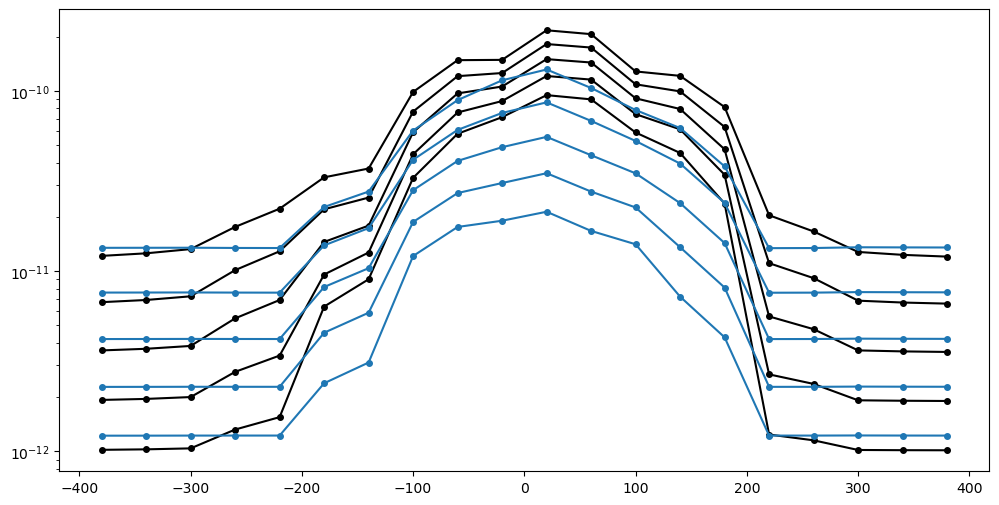

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, -n_times_invert:], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_reshaped[ind, :, :], "-oC0", ms=4);

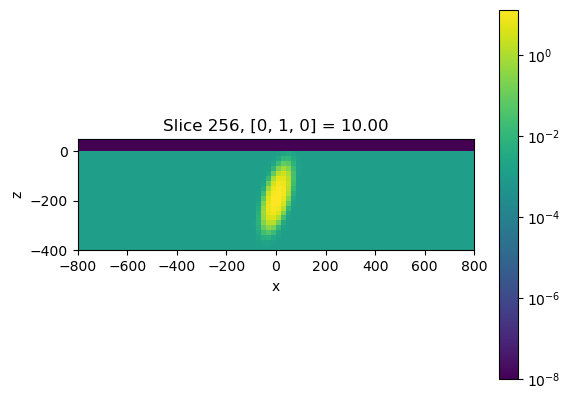

In [52]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * mopt_parametric, normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [53]:
data_invert_full = Data(
    survey, dobs=dobs,
    standard_deviation=np.abs(dobs)*relative_error + noise_floor
)

In [54]:
# set up an inversion now using the parametric as a reference model
dmis_full = data_misfit.L2DataMisfit(simulation=sim, data=data_invert_full)
reg = regularization.WeightedLeastSquares(
    global_mesh,
    active_cells = active_cells_map.active_cells,
    # reference_model = global_ellipsoid * mopt_parametric,
    reference_model = np.ones(active_cells_map.active_cells.sum()) * np.log(sigma_back),
    # alpha_s=1,
)


In [55]:
opt = optimization.InexactGaussNewton(maxIter=4)
inv_prob = inverse_problem.BaseInvProblem(dmis_full, reg, opt)


In [80]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=100, n_pw_iter=2)
cool_beta = directives.BetaSchedule(coolingFactor=2, coolingRate=1)
# Options for outputting recovered models and predicted data for each beta.
save_iteration = directives.SaveOutputDictEveryIteration(
    # saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

In [81]:
# The directives are defined as a list.
directives_list = [
    starting_beta,
    cool_beta,
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

The callback on the InexactGaussNewton minimizer was replaced.


In [82]:
# m0 = np.ones(active_cells_map.active_cells.sum()) * np.log(sigma_back)
m0 = global_ellipsoid * mopt_parametric

In [ ]:
mrec = inv.run(m0)
# mrec = np.load("mrec_full.npy")

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.24.1.dev33+g42a5db944


INFO: Directive TargetMisfit: Target data misfit is 1200.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  8.18e-06  2.81e+04  9.83e+09  1.09e+05                                 
   1  8.18e-06  9.59e+03  8.83e+09  8.19e+04    6.97e+04      0              


In [65]:
# out = np.load("InversionModel_2026-06-11-10-13_01.npz", allow_pickle=True)["arr_0"].item()
# mrec = out["m"]

In [78]:
save_iteration.outDict[4]["m"]

array([-6.77450517, -6.77450517, -6.77450517, ..., -6.77450523,
       -6.77450523, -6.77450518])

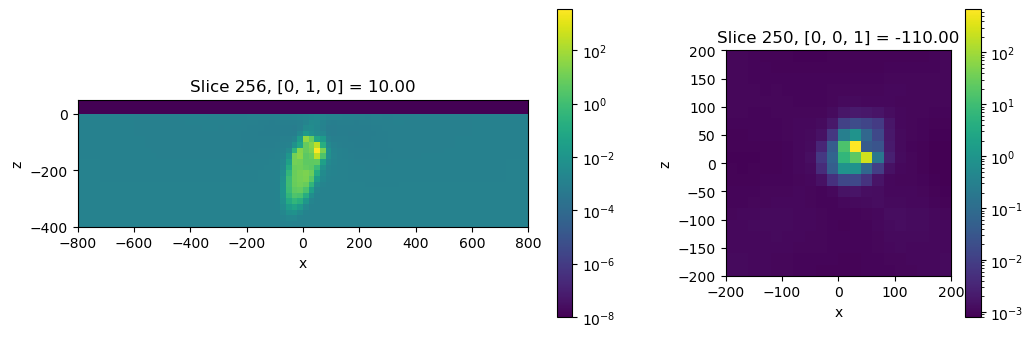

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios":[2,1]})
iteration = 4
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*save_iteration.outDict[iteration]["m"], normal="y", ax=ax[0],
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax[0]
)

plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*save_iteration.outDict[iteration]["m"], normal="z", ax=ax[1],
        pcolor_opts={"norm":LogNorm()},
        ind=250,
        )[0],
    ax=ax[1]
)

ax[0].set_xlim(800*np.r_[-1, 1])
ax[0].set_ylim(np.r_[-400, 50])

ax[1].set_xlim(200*np.r_[-1, 1])
ax[1].set_ylim(200*np.r_[-1, 1])

for a in ax.flatten():
    a.set_aspect(1)

In [72]:
dpred_reshaped = save_iteration.outDict[iteration]["dpred"].reshape(len(rx_y), len(rx_x), -1)

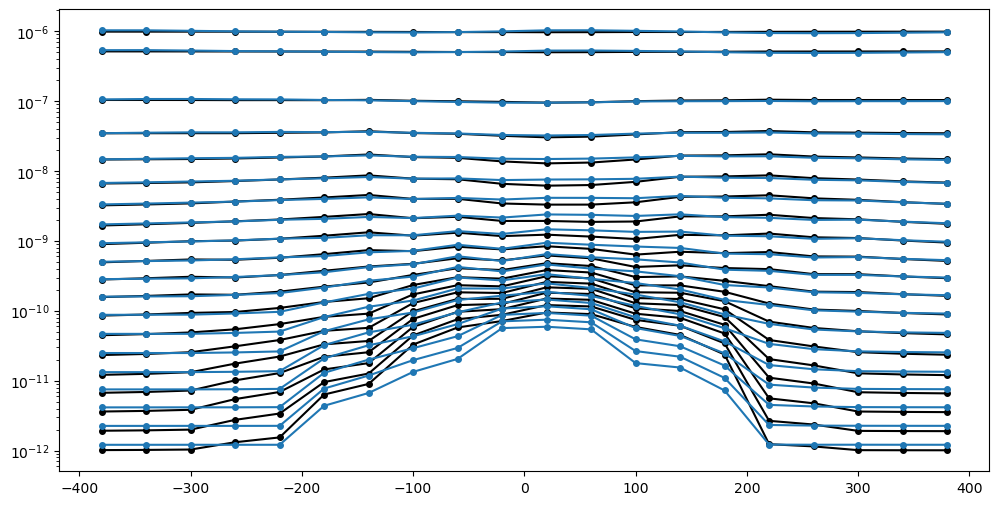

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 1
ax.semilogy(rx_x, -dobs_reshaped[ind, :, :], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_reshaped[ind, :, :], "-oC0", ms=4);